In [1]:
library(tidyverse)
library(ComplexHeatmap)
library(reshape2)

── Attaching core tidyverse packages ──────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.

In [2]:
# see 'Fig4E_S9B : scenicplus_eRegulon_AUC.ipynb' to know how to make AUC_test.csv file
df <- read.csv('data/scenicplus/AUC_test.csv',row.names = 1) 

In [3]:
seq <- c(paste0(c('Thra','Tfap2b','Tcf12','Sp4','Sp3','Smad3','Rorb','Rfx3','Rarb','Pura',
         'Pou6f1','Pbx3','Pbx1','Pax6','Nrf1','Nr1d2','Nfix','Nfic','Nfib','Nfia',
         'Myef2','Meis2','Meis1','Mef2d','Mafg','Maf','Isl1','Esrrb','Esrra','E2f3',
         'Ctcf','Cnot3','Atf7','Atf2','Sox5','Phf21a','Esrrg','Ebf3','Chd2','Tfap2d',
         'Tbx20','Rora','Pou4f1','Onecut1','Fosl2','Eomes','Ebf1','Bach2'),' (+)'),
          paste0(c('Rora','Ebf1','Thrb','Tbx20','Nfib','Mef2c','Ebf3'),' (-)'))

In [4]:
reg <- rownames(df) %>% sapply(.,function(x){strsplit(x,split='/')[[1]][1]}) %>% gsub('_direct_',' (',.) %>% paste0(.,')')
rownames(df) <- reg
df <- df[seq,]

In [5]:
value_mat <- as.matrix(df[, grep("^diff", colnames(df))])

In [6]:
pval_mat <- as.matrix(df[, grep("^padj", colnames(df))])

In [7]:
get_sig_tags <- function(p) {
  ifelse(p < 0.001, "***",
    ifelse(p < 0.01, "**",
      ifelse(p < 0.05, "*", "")))
}

In [8]:
display_mat <- apply(pval_mat, c(1, 2), get_sig_tags)

In [9]:
my_color = colorRampPalette(c("#7CDAC2", "white", "#DA5E16"))(100)

In [10]:
cell_fun = function(j, i, x, y, width, height, fill) {
    grid.text(display_mat[i, j], x, y, gp = gpar(fontsize = 14, col = "black"))
}

In [11]:
row_split <- factor(c(rep("activator", nrow(value_mat)-7), rep("repressor", 7)), 
                    levels = c("activator", "repressor"))

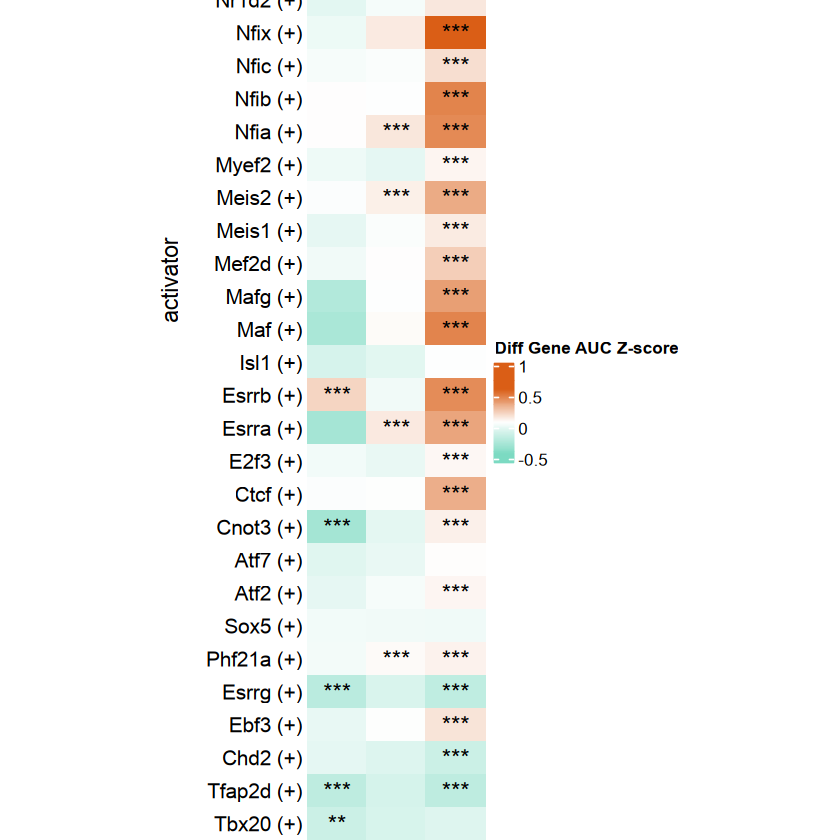

In [12]:
Heatmap(
  value_mat,
  cluster_columns = FALSE,
  cluster_rows = FALSE,
  split = row_split,
  gap = unit(3, "mm"),
  cluster_row_slices = FALSE,
  col = my_color,
  rect_gp = gpar(col = NA),
  cell_fun = cell_fun,
  row_names_side = "left",
  column_names_side = "bottom",
  column_names_rot = 45,
  column_names_gp = gpar(fontsize = 12),
  row_names_gp = gpar(fontsize = 12),
  width = unit(ncol(value_mat) * 35.7, "pt"),
  height = unit(nrow(value_mat) * 20, "pt"),
  column_title = "Gene AUC Difference of Regulons",
  heatmap_legend_param = list(title = "Diff Gene AUC Z-score"),
  show_heatmap_legend = TRUE
)